<a href="https://colab.research.google.com/github/syntizen/Union-Chess/blob/main/Union_chess_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import random
import copy
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output

class ChessPiece:
    def __init__(self, name, color):
        self.name = name
        self.color = color

    def __str__(self):
        return f"{self.color[0]}{self.name[0]}"

class ChessGame:
    def __init__(self):
        self.rows = 16
        self.cols = 24
        self.board = self.create_board()
        self.current_turn = "White"
        self.moves_left_this_turn = 3

    def create_board(self):
        board = [[None for _ in range(self.cols)] for _ in range(self.rows)]

        # Setup pieces for White
        white_pieces_order = ["Rook", "Knight", "Bishop", "Queen", "King", "Bishop", "Knight", "Rook"] * 3
        for i in range(self.cols):
            board[1][i] = ChessPiece("Pawn", "White")
            board[0][i] = ChessPiece(white_pieces_order[i], "White")

        # Setup pieces for Black
        black_pieces_order = list(reversed(white_pieces_order))
        for i in range(self.cols):
            board[14][i] = ChessPiece("Pawn", "Black")
            board[15][i] = ChessPiece(black_pieces_order[i], "Black")

        return board

    def get_valid_moves(self, r, c):
        piece = self.board[r][c]
        if not piece or piece.color != self.current_turn:
            return []

        moves = []
        name = piece.name

        # --- PAWN MOVES ---
        if name == "Pawn":
            direction = 1 if piece.color == "White" else -1
            start_row = 1 if piece.color == "White" else 14

            if 0 <= r + direction < self.rows and self.board[r + direction][c] is None:
                moves.append((r + direction, c))
                if r == start_row and self.board[r + 2 * direction][c] is None:
                    moves.append((r + 2 * direction, c))
            for dc in [-1, 1]:
                target_c = c + dc
                target_r = r + direction
                if 0 <= target_r < self.rows and 0 <= target_c < self.cols:
                    target = self.board[target_r][target_c]
                    if target and target.color != piece.color:
                        moves.append((target_r, target_c))

        # --- KNIGHT MOVES ---
        elif name == "Knight":
            offsets = [(-2,-1), (-2,1), (-1,-2), (-1,2), (1,-2), (1,2), (2,-1), (2,1)]
            for dr, dc in offsets:
                tr, tc = r + dr, c + dc
                if 0 <= tr < self.rows and 0 <= tc < self.cols:
                    if self.board[tr][tc] is None or self.board[tr][tc].color != piece.color:
                        moves.append((tr, tc))

        # --- SLIDING PIECES (Rook, Bishop, Queen, King) ---
        else:
            directions = []
            max_step = max(self.rows, self.cols)
            if name in ["Rook", "Queen"]:
                directions.extend([(-1,0), (1,0), (0,-1), (0,1)])
            if name in ["Bishop", "Queen"]:
                directions.extend([(-1,-1), (-1,1), (1,-1), (1,1)])
            if name == "King":
                directions.extend([(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)])
                max_step = 1

            for dr, dc in directions:
                for step in range(1, max_step + 1):
                    tr, tc = r + dr * step, c + dc * step
                    if not (0 <= tr < self.rows and 0 <= tc < self.cols):
                        break
                    target = self.board[tr][tc]
                    if target is None:
                        moves.append((tr, tc))
                    elif target.color != piece.color:
                        moves.append((tr, tc))
                        break
                    else:
                        break
        return moves

    def get_all_legal_moves(self, color):
        all_moves = []
        for r in range(self.rows):
            for c in range(self.cols):
                piece = self.board[r][c]
                if piece and piece.color == color:
                    valid_to_squares = self.get_valid_moves(r, c)
                    for tr, tc in valid_to_squares:
                        all_moves.append(((r, c), (tr, tc)))
        return all_moves

    def count_kings(self):
        """Counts how many Kings each color has left on the board."""
        counts = {"White": 0, "Black": 0}
        for row in self.board:
            for piece in row:
                if piece and piece.name == "King":
                    counts[piece.color] += 1
        return counts

    def make_move(self, from_sq, to_sq):
        fr, fc = from_sq
        tr, tc = to_sq

        piece = self.board[fr][fc]
        self.board[tr][tc] = piece
        self.board[fr][fc] = None

        self.moves_left_this_turn -= 1
        if self.moves_left_this_turn == 0:
            self.current_turn = "Black" if self.current_turn == "White" else "White"
            self.moves_left_this_turn = 3

class ChessRobot:
    def __init__(self, color):
        self.color = color
        self.piece_values = {"Pawn": 10, "Knight": 30, "Bishop": 30, "Rook": 50, "Queen": 90, "King": 1000}

    def evaluate_board(self, board):
        score = 0
        for r in range(len(board)):
            for c in range(len(board[0])):
                piece = board[r][c]
                if piece:
                    val = self.piece_values.get(piece.name, 0)
                    if piece.color == self.color:
                        score += val
                    else:
                        score -= val
        return score

    def select_best_move(self, game):
        legal_moves = game.get_all_legal_moves(self.color)
        if not legal_moves:
            return None

        best_score = -float('inf')
        best_moves = []

        for move in legal_moves:
            from_sq, to_sq = move
            temp_game = copy.deepcopy(game)
            temp_game.make_move(from_sq, to_sq)

            score = self.evaluate_board(temp_game.board)

            # Positional bonus to encourage progressive play
            direction = 1 if self.color == "White" else -1
            score += (to_sq[0] - from_sq[0]) * direction * 0.2

            if score > best_score:
                best_score = score
                best_moves = [move]
            elif score == best_score:
                best_moves.append(move)

        return random.choice(best_moves) if best_moves else None

# --- DYNAMIC RENDERING ENGINE ---
def draw_live_chessboard(game, last_action_text="", fig=None, ax=None):
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(15, 9))
    else:
        ax.clear()

    ax.set_xlim([0, game.cols])
    ax.set_ylim([0, game.rows])

    for x in range(game.cols):
        for y in range(game.rows):
            color = '#f0d9b5' if (x + y) % 2 == 0 else '#b58863'
            rect = patches.Rectangle((x, y), 1, 1, facecolor=color)
            ax.add_patch(rect)

            piece = game.board[y][x]
            if piece:
                text_color = 'white' if piece.color == 'White' else 'black'
                bbox_props = dict(boxstyle="circle,pad=0.2", fc="black" if piece.color=='White' else "white", ec="none", alpha=0.6)
                ax.text(x + 0.5, y + 0.5, str(piece), fontsize=8, weight='bold',
                        ha='center', va='center', color=text_color, bbox=bbox_props)

    ax.set_aspect('equal', adjustable='box')

    kings = game.count_kings()
    title_text = (f"Turn: {game.current_turn} | Action: {4 - game.moves_left_this_turn}/3\n"
                  f"White Kings Left: {kings['White']} | Black Kings Left: {kings['Black']}\n"
                  f"Latest Log: {last_action_text}")
    ax.set_title(title_text, fontsize=12, weight='bold')
    ax.grid(False)

    clear_output(wait=True)
    display(fig)
    plt.close(fig) # Prevent ghosting plots

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


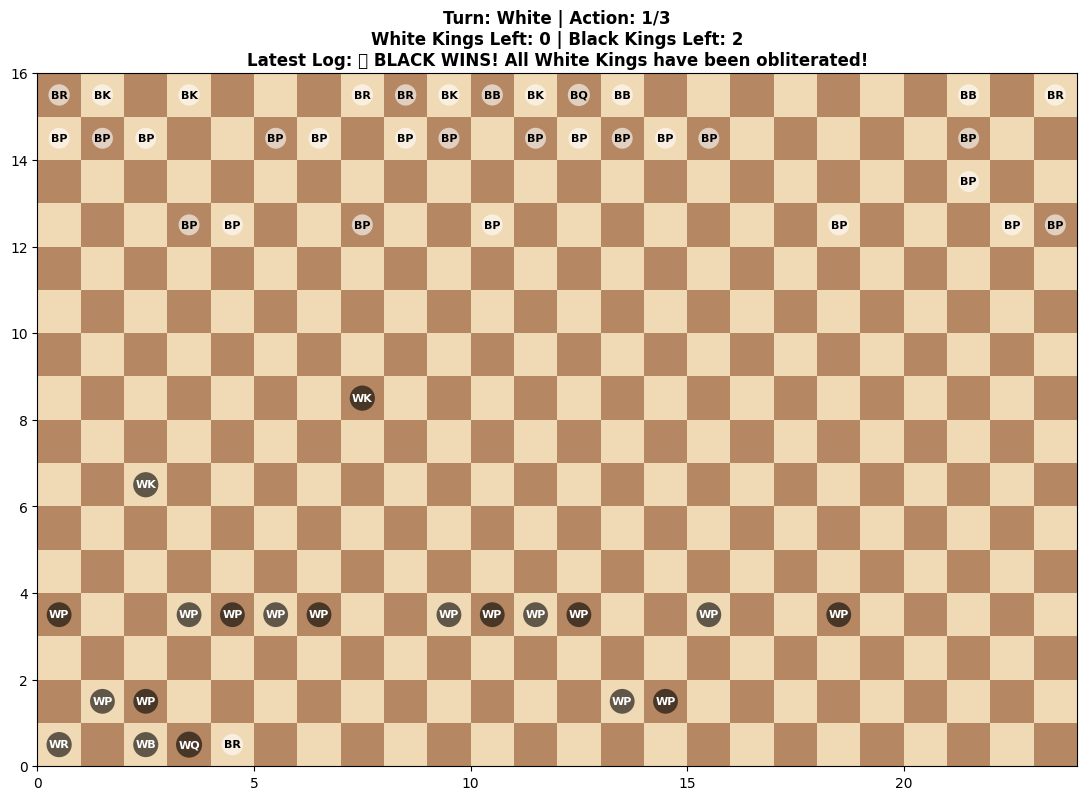

In [4]:
# Create Game Instance
game = ChessGame()
white_bot = ChessRobot("White")
black_bot = ChessRobot("Black")

# Prepare a single global figure frame for animating
fig, ax = plt.subplots(figsize=(15, 9))
last_text = "Game Started!"

# Initial draw
draw_live_chessboard(game, last_text, fig, ax)

# Game Loop
move_counter = 1
while True:
    # Check Win/Loss conditions
    king_counts = game.count_kings()
    if king_counts["White"] == 0:
        draw_live_chessboard(game, "🏆 BLACK WINS! All White Kings have been obliterated!", fig, ax)
        break
    if king_counts["Black"] == 0:
        draw_live_chessboard(game, "🏆 WHITE WINS! All Black Kings have been obliterated!", fig, ax)
        break

    current_color = game.current_turn
    bot = white_bot if current_color == "White" else black_bot

    # Get move selection
    chosen_move = bot.select_best_move(game)

    if chosen_move:
        from_sq, to_sq = chosen_move
        moving_piece = game.board[from_sq[0]][from_sq[1]]
        target_square = game.board[to_sq[0]][to_sq[1]]

        # Build telemetry log string
        capture_log = f" (Captured {target_square.color} {target_square.name}!)" if target_square else ""
        last_text = f"[Move {move_counter}] {current_color} moved {moving_piece.name} from {from_sq} to {to_sq}{capture_log}"

        # Process move state transitions
        game.make_move(from_sq, to_sq)
        move_counter += 1

        # Live redraw on the SAME window space
        draw_live_chessboard(game, last_text, fig, ax)

        # Adjust sleep time (in seconds) to speed up or slow down the simulation
        time.sleep(0.1)
    else:
        # Handling stalemates or sudden blocked paths
        last_text = f"Game Over! {current_color} has no legal moves left. Draw by stalemate."
        draw_live_chessboard(game, last_text, fig, ax)
        break

In [15]:
import random
import copy
import time
from ipywidgets import HTML
from IPython.display import display

class ChessPiece:
    def __init__(self, name, color):
        self.name = name
        self.color = color

    def __str__(self):
        return f"{self.color[0]}{self.name[0]}"

class ChessGame:
    def __init__(self):
        self.rows = 16
        self.cols = 24
        self.board = self.create_board()
        self.current_turn = "White"
        self.moves_left_this_turn = 3
        self.moved_pieces_this_turn = set()

        self.turn_origins = []
        self.turn_destinations = []
        self.turn_paths = set()

    def create_board(self):
        board = [[None for _ in range(self.cols)] for _ in range(self.rows)]

        white_pieces_order = ["Rook", "Knight", "Bishop", "Queen", "King", "Bishop", "Knight", "Rook"] * 3
        for i in range(self.cols):
            board[1][i] = ChessPiece("Pawn", "White")
            board[0][i] = ChessPiece(white_pieces_order[i], "White")

        black_pieces_order = list(reversed(white_pieces_order))
        for i in range(self.cols):
            board[14][i] = ChessPiece("Pawn", "Black")
            board[15][i] = ChessPiece(black_pieces_order[i], "Black")

        return board

    def get_valid_moves(self, r, c):
        piece = self.board[r][c]
        if not piece or piece.color != self.current_turn:
            return []
        if (r, c) in self.moved_pieces_this_turn:
            return []

        moves = []
        name = piece.name

        # --- PAWN MOVES ---
        if name == "Pawn":
            direction = 1 if piece.color == "White" else -1
            start_row = 1 if piece.color == "White" else 14

            if 0 <= r + direction < self.rows and self.board[r + direction][c] is None:
                moves.append((r + direction, c))
                if r == start_row and self.board[r + 2 * direction][c] is None:
                    moves.append((r + 2 * direction, c))
            for dc in [-1, 1]:
                target_c = c + dc
                target_r = r + direction
                if 0 <= target_r < self.rows and 0 <= target_c < self.cols:
                    target = self.board[target_r][target_c]
                    if target and target.color != piece.color:
                        moves.append((target_r, target_c))

        # --- KNIGHT MOVES ---
        elif name == "Knight":
            offsets = [(-2,-1), (-2,1), (-1,-2), (-1,2), (1,-2), (1,2), (2,-1), (2,1)]
            for dr, dc in offsets:
                tr, tc = r + dr, c + dc
                if 0 <= tr < self.rows and 0 <= tc < self.cols:
                    if self.board[tr][tc] is None or self.board[tr][tc].color != piece.color:
                        moves.append((tr, tc))

        # --- SLIDING PIECES (Rook, Bishop, Queen, King) ---
        else:
            directions = []
            max_step = max(self.rows, self.cols)
            if name in ["Rook", "Queen"]:
                directions.extend([(-1,0), (1,0), (0,-1), (0,1)])
            if name in ["Bishop", "Queen"]:
                directions.extend([(-1,-1), (-1,1), (1,-1), (1,1)])
            if name == "King":
                directions.extend([(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)])
                max_step = 1

            for dr, dc in directions:
                for step in range(1, max_step + 1):
                    tr, tc = r + dr * step, c + dc * step
                    if not (0 <= tr < self.rows and 0 <= tc < self.cols):
                        break
                    target = self.board[tr][tc]
                    if target is None:
                        moves.append((tr, tc))
                    elif target.color != piece.color:
                        moves.append((tr, tc))
                        break
                    else:
                        break
        return moves

    def get_all_legal_moves(self, color):
        all_moves = []
        for r in range(self.rows):
            for c in range(self.cols):
                piece = self.board[r][c]
                if piece and piece.color == color:
                    valid_to_squares = self.get_valid_moves(r, c)
                    for tr, tc in valid_to_squares:
                        all_moves.append(((r, c), (tr, tc)))
        return all_moves

    def calculate_path(self, from_sq, to_sq):
        fr, fc = from_sq
        tr, tc = to_sq
        piece = self.board[fr][fc]

        path_cells = []
        if not piece or piece.name == "Knight":
            return path_cells

        dr = tr - fr
        dc = tc - fc

        step_r = (dr // abs(dr)) if dr != 0 else 0
        step_c = (dc // abs(dc)) if dc != 0 else 0

        curr_r, curr_c = fr + step_r, fc + step_c
        while (curr_r, curr_c) != (tr, tc):
            path_cells.append((curr_r, curr_c))
            curr_r += step_r
            curr_c += step_c

        return path_cells

    def count_kings(self):
        counts = {"White": 0, "Black": 0}
        for row in self.board:
            for piece in row:
                if piece and piece.name == "King":
                    counts[piece.color] += 1
        return counts

    def clear_turn_highlights(self):
        self.turn_origins.clear()
        self.turn_destinations.clear()
        self.turn_paths.clear()

    def make_move(self, from_sq, to_sq):
        self.turn_origins.append(from_sq)
        self.turn_destinations.append(to_sq)
        self.turn_paths.update(self.calculate_path(from_sq, to_sq))

        fr, fc = from_sq
        tr, tc = to_sq

        piece = self.board[fr][fc]
        self.board[tr][tc] = piece
        self.board[fr][fc] = None

        self.moved_pieces_this_turn.add((tr, tc))
        self.moves_left_this_turn -= 1

        if self.moves_left_this_turn == 0:
            self.current_turn = "Black" if self.current_turn == "White" else "White"
            self.moves_left_this_turn = 3
            self.moved_pieces_this_turn.clear()

class ChessRobot:
    def __init__(self, color):
        self.color = color
        self.piece_values = {"Pawn": 10, "Knight": 30, "Bishop": 30, "Rook": 50, "Queen": 90, "King": 1000}

    def evaluate_board(self, board):
        score = 0
        for r in range(len(board)):
            for c in range(len(board[0])):
                piece = board[r][c]
                if piece:
                    val = self.piece_values.get(piece.name, 0)
                    if piece.color == self.color:
                        score += val
                    else:
                        score -= val
        return score

    def select_best_move(self, game):
        legal_moves = game.get_all_legal_moves(self.color)
        if not legal_moves:
            return None

        best_score = -float('inf')
        best_moves = []

        for move in legal_moves:
            from_sq, to_sq = move
            temp_game = copy.deepcopy(game)
            temp_game.make_move(from_sq, to_sq)

            score = self.evaluate_board(temp_game.board)

            direction = 1 if self.color == "White" else -1
            score += (to_sq[0] - from_sq[0]) * direction * 0.2

            if score > best_score:
                best_score = score
                best_moves = [move]
            elif score == best_score:
                best_moves.append(move)

        return random.choice(best_moves) if best_moves else None

# --- HTML MULTI-TRAIL RENDERING ENGINE (COLOR FIX APPLIED) ---
def generate_board_html(game, turn_summary_logs=[], turn_counter=0):
    kings = game.count_kings()
    logs_html = "".join([f"<div style='margin-top:2px;'>• {log}</div>" for log in turn_summary_logs])
    if not logs_html:
        logs_html = "Waiting for game initialization..."

    html = f"""
    <div style="font-family: monospace; background-color: #222; color: #fff; padding: 15px; border-radius: 8px; width: 820px; margin-bottom: 10px;">
        <div style="font-size: 16px; font-weight: bold; margin-bottom: 5px; color: #4af;">
            NEXT TEAM TO ACT: {game.current_turn.upper()} &nbsp;|&nbsp; Completed Full Turns: {turn_counter}
        </div>
        <div style="font-size: 13px; margin-bottom: 8px;">
            <span style="color: #fff; font-weight:bold;">🤍 White Kings: {kings['White']}</span> &nbsp;&nbsp;&nbsp;&nbsp;
            <span style="color: #aaa; font-weight:bold;">🖤 Black Kings: {kings['Black']}</span>
        </div>
        <div style="background: #333; padding: 8px 12px; border-left: 4px solid #4af; font-size: 12px; color: #ddd; line-height: 1.4;">
            <b>Full Turn Formation Actions:</b>
            {logs_html}
        </div>
    </div>
    <table style="border-collapse: collapse; border: 3px solid #333; font-family: sans-serif;">
    """

    for r in range(game.rows - 1, -1, -1):
        html += "<tr>"
        for c in range(game.cols):
            is_light = (r + c) % 2 != 0
            bg_color = "#f0d9b5" if is_light else "#b58863"

            if (r, c) in game.turn_destinations:
                bg_color = "#4682B4"
            elif (r, c) in game.turn_origins:
                bg_color = "#DEB887"
            elif (r, c) in game.turn_paths:
                bg_color = "#B0E0E6"

            piece = game.board[r][c]
            piece_html = ""

            if piece:
                # FIXED LOGIC: White pieces get a white circle background with black text.
                # Black pieces get a dark charcoal background with white text.
                p_bg = "#ffffff" if piece.color == "White" else "#2c2c2c"
                p_color = "#000000" if piece.color == "White" else "#ffffff"
                border_stroke = "1px solid #000" if piece.color == "White" else "1px solid #fff"

                piece_html = f"""
                <div style="width: 26px; height: 26px; line-height: 26px; border-radius: 50%;
                     background-color: {p_bg}; color: {p_color}; font-weight: bold; font-size: 11px;
                     text-align: center; margin: auto; border: {border_stroke}; box-shadow: 1px 1px 3px rgba(0,0,0,0.4);">
                    {str(piece)}
                </div>
                """

            html += f"""
            <td style="width: 32px; height: 32px; background-color: {bg_color}; text-align: center; vertical-align: middle; padding: 0; border: 1px solid rgba(0,0,0,0.05);">
                {piece_html}
            </td>
            """
        html += "</tr>"

    html += "</table>"
    return html

In [16]:
# Create Engine & Robot States
game = ChessGame()
white_bot = ChessRobot("White")
black_bot = ChessRobot("Black")

board_widget = HTML(value=generate_board_html(game, ["Game initialization phase."], 0))
display(board_widget)

turn_counter = 0

while True:
    king_counts = game.count_kings()
    if king_counts["White"] == 0:
        board_widget.value = generate_board_html(game, ["🏆 GAME OVER - BLACK WINS!"], turn_counter)
        break
    if king_counts["Black"] == 0:
        board_widget.value = generate_board_html(game, ["🏆 GAME OVER - WHITE WINS!"], turn_counter)
        break

    active_color = game.current_turn
    bot = white_bot if active_color == "White" else black_bot

    game.clear_turn_highlights()
    turn_summary_logs = []

    actions_taken = 0
    for step in range(3):
        if game.count_kings()["White" if active_color == "Black" else "Black"] == 0:
            break

        chosen_move = bot.select_best_move(game)
        if chosen_move:
            from_sq, to_sq = chosen_move
            moving_piece = game.board[from_sq[0]][from_sq[1]]
            target_square = game.board[to_sq[0]][to_sq[1]]

            boxes_traveled = max(abs(to_sq[0] - from_sq[0]), abs(to_sq[1] - from_sq[1]))
            capture_note = f" (Captured {target_square.color} {target_square.name}!)" if target_square else ""
            turn_summary_logs.append(f"Action {step+1}: {moving_piece.name} moved {boxes_traveled} blocks from {from_sq} to {to_sq}{capture_note}")

            game.make_move(from_sq, to_sq)
            actions_taken += 1
        else:
            break

    if actions_taken == 0:
        board_widget.value = generate_board_html(game, [f"Stalemate! {active_color} is blocked."], turn_counter)
        break

    turn_counter += 1
    board_widget.value = generate_board_html(game, turn_summary_logs, turn_counter)
    time.sleep(1.2)

HTML(value='\n    <div style="font-family: monospace; background-color: #222; color: #fff; padding: 15px; bord…

KeyboardInterrupt: 

In [19]:
import random
import copy
import time
from ipywidgets import HTML
from IPython.display import display

class ChessPiece:
    def __init__(self, name, color):
        self.name = name
        self.color = color

    def __str__(self):
        return f"{self.color[0]}{self.name[0]}"

class ChessGame:
    def __init__(self):
        self.rows = 16
        self.cols = 24
        self.board = self.create_board()
        self.current_turn = "White"
        self.moves_left_this_turn = 3
        self.moved_pieces_this_turn = set()

        # Tracking variables for current visual animation frames
        self.animating_piece = None
        self.animating_pos = None # (r, c)

    def create_board(self):
        board = [[None for _ in range(self.cols)] for _ in range(self.rows)]

        white_pieces_order = ["Rook", "Knight", "Bishop", "Queen", "King", "Bishop", "Knight", "Rook"] * 3
        for i in range(self.cols):
            board[1][i] = ChessPiece("Pawn", "White")
            board[0][i] = ChessPiece(white_pieces_order[i], "White")

        black_pieces_order = list(reversed(white_pieces_order))
        for i in range(self.cols):
            board[14][i] = ChessPiece("Pawn", "Black")
            board[15][i] = ChessPiece(black_pieces_order[i], "Black")

        return board

    def get_valid_moves(self, r, c):
        piece = self.board[r][c]
        if not piece or piece.color != self.current_turn:
            return []
        if (r, c) in self.moved_pieces_this_turn:
            return []

        moves = []
        name = piece.name

        # --- PAWN MOVES ---
        if name == "Pawn":
            direction = 1 if piece.color == "White" else -1
            start_row = 1 if piece.color == "White" else 14

            if 0 <= r + direction < self.rows and self.board[r + direction][c] is None:
                moves.append((r + direction, c))
                if r == start_row and self.board[r + 2 * direction][c] is None:
                    moves.append((r + 2 * direction, c))
            for dc in [-1, 1]:
                target_c = c + dc
                target_r = r + direction
                if 0 <= target_r < self.rows and 0 <= target_c < self.cols:
                    target = self.board[target_r][target_c]
                    if target and target.color != piece.color:
                        moves.append((target_r, target_c))

        # --- KNIGHT MOVES ---
        elif name == "Knight":
            offsets = [(-2,-1), (-2,1), (-1,-2), (-1,2), (1,-2), (1,2), (2,-1), (2,1)]
            for dr, dc in offsets:
                tr, tc = r + dr, c + dc
                if 0 <= tr < self.rows and 0 <= tc < self.cols:
                    if self.board[tr][tc] is None or self.board[tr][tc].color != piece.color:
                        moves.append((tr, tc))

        # --- SLIDING PIECES (Rook, Bishop, Queen, King) ---
        else:
            directions = []
            max_step = max(self.rows, self.cols)
            if name in ["Rook", "Queen"]:
                directions.extend([(-1,0), (1,0), (0,-1), (0,1)])
            if name in ["Bishop", "Queen"]:
                directions.extend([(-1,-1), (-1,1), (1,-1), (1,1)])
            if name == "King":
                directions.extend([(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)])
                max_step = 1

            for dr, dc in directions:
                for step in range(1, max_step + 1):
                    tr, tc = r + dr * step, c + dc * step
                    if not (0 <= tr < self.rows and 0 <= tc < self.cols):
                        break
                    target = self.board[tr][tc]
                    if target is None:
                        moves.append((tr, tc))
                    elif target.color != piece.color:
                        moves.append((tr, tc))
                        break
                    else:
                        break
        return moves

    def get_all_legal_moves(self, color):
        all_moves = []
        for r in range(self.rows):
            for c in range(self.cols):
                piece = self.board[r][c]
                if piece and piece.color == color:
                    valid_to_squares = self.get_valid_moves(r, c)
                    for tr, tc in valid_to_squares:
                        all_moves.append(((r, c), (tr, tc)))
        return all_moves

    def calculate_path_points(self, from_sq, to_sq):
        fr, fc = from_sq
        tr, tc = to_sq
        piece = self.board[fr][fc]

        if not piece:
            return [(fr, fc), (tr, tc)]

        if piece.name == "Knight":
            return [(fr, fc), (tr, fc), (tr, tc)]

        dr = tr - fr
        dc = tc - fc
        steps = max(abs(dr), abs(dc))

        if steps == 0:
            return [(fr, fc)]

        path = []
        for i in range(steps + 1):
            curr_r = fr + (dr * i) // steps
            curr_c = fc + (dc * i) // steps
            path.append((curr_r, curr_c))
        return path

    def count_kings(self):
        counts = {"White": 0, "Black": 0}
        for row in self.board:
            for piece in row:
                if piece and piece.name == "King":
                    counts[piece.color] += 1
        return counts

    def finalize_move_data(self, from_sq, to_sq):
        fr, fc = from_sq
        tr, tc = to_sq

        piece = self.board[fr][fc]
        self.board[tr][tc] = piece
        self.board[fr][fc] = None

        self.moved_pieces_this_turn.add((tr, tc))
        self.moves_left_this_turn -= 1

        if self.moves_left_this_turn == 0:
            self.current_turn = "Black" if self.current_turn == "White" else "White"
            self.moves_left_this_turn = 3
            self.moved_pieces_this_turn.clear()

class ChessRobot:
    def __init__(self, color):
        self.color = color
        self.piece_values = {"Pawn": 10, "Knight": 30, "Bishop": 30, "Rook": 50, "Queen": 90, "King": 1000}

    def evaluate_board(self, board):
        score = 0
        for r in range(len(board)):
            for c in range(len(board[0])):
                piece = board[r][c]
                if piece:
                    val = self.piece_values.get(piece.name, 0)
                    if piece.color == self.color:
                        score += val
                    else:
                        score -= val
        return score

    def select_best_move(self, game):
        legal_moves = game.get_all_legal_moves(self.color)
        if not legal_moves:
            return None

        best_score = -float('inf')
        best_moves = []

        for move in legal_moves:
            from_sq, to_sq = move
            temp_game = copy.deepcopy(game)
            temp_game.finalize_move_data(from_sq, to_sq)

            score = self.evaluate_board(temp_game.board)

            direction = 1 if self.color == "White" else -1
            score += (to_sq[0] - from_sq[0]) * direction * 0.2

            if score > best_score:
                best_score = score
                best_moves = [move]
            elif score == best_score:
                best_moves.append(move)

        return random.choice(best_moves) if best_moves else None

# --- HTML RENDERING ENGINE (WITH FIXED CONTAINER HEIGHTS TO PREVENT SHIFTING) ---
def generate_board_html(game, current_logs=[], turn_counter=0):
    kings = game.count_kings()
    logs_html = "".join([f"<div style='margin-top:2px;'>• {log}</div>" for log in current_logs])
    if not logs_html:
        logs_html = "Processing..."

    # Crucial Layout fix: added fixed vertical heights to container boxes (height: 54px;)
    # to stop dynamic line updates from shifting the chessboard grid.
    html = f"""
    <div style="font-family: monospace; background-color: #222; color: #fff; padding: 15px; border-radius: 8px; width: 820px; margin-bottom: 10px; box-sizing: border-box;">
        <div style="font-size: 16px; font-weight: bold; margin-bottom: 5px; color: #4af;">
            CURRENT TEAM TURN: {game.current_turn.upper()} &nbsp;|&nbsp; Total Complete Turns: {turn_counter}
        </div>
        <div style="font-size: 13px; margin-bottom: 8px;">
            <span style="color: #fff; font-weight:bold;">🤍 White Kings: {kings['White']}</span> &nbsp;&nbsp;&nbsp;&nbsp;
            <span style="color: #aaa; font-weight:bold;">🖤 Black Kings: {kings['Black']}</span>
        </div>
        <div style="background: #333; padding: 8px 12px; border-left: 4px solid #4af; font-size: 12px; color: #ddd; line-height: 1.4; height: 54px; overflow-y: auto; box-sizing: border-box;">
            <b>Live Actions Output Tracker:</b>
            {logs_html}
        </div>
    </div>
    <table style="border-collapse: collapse; border: 3px solid #333; font-family: sans-serif;">
    """

    for r in range(game.rows - 1, -1, -1):
        html += "<tr>"
        for c in range(game.cols):
            is_light = (r + c) % 2 != 0
            bg_color = "#f0d9b5" if is_light else "#b58863"

            piece = game.board[r][c]
            piece_html = ""

            active_render_piece = piece
            if game.animating_piece and game.animating_pos == (r, c):
                active_render_piece = game.animating_piece

            if active_render_piece:
                p_bg = "#ffffff" if active_render_piece.color == "White" else "#2c2c2c"
                p_color = "#000000" if active_render_piece.color == "White" else "#ffffff"
                border_stroke = "1px solid #000" if active_render_piece.color == "White" else "1px solid #fff"

                shadow = "3px 3px 7px rgba(0,0,0,0.5)" if (game.animating_piece and game.animating_pos == (r, c)) else "1px 1px 3px rgba(0,0,0,0.3)"

                piece_html = f"""
                <div style="width: 26px; height: 26px; line-height: 26px; border-radius: 50%;
                     background-color: {p_bg}; color: {p_color}; font-weight: bold; font-size: 11px;
                     text-align: center; margin: auto; border: {border_stroke}; box-shadow: {shadow}; transition: all 0.04s ease;">
                    {str(active_render_piece)}
                </div>
                """

            html += f"""
            <td style="width: 32px; height: 32px; background-color: {bg_color}; text-align: center; vertical-align: middle; padding: 0; border: 1px solid rgba(0,0,0,0.05);">
                {piece_html}
            </td>
            """
        html += "</tr>"

    html += "</table>"
    return html

In [22]:
# Initialize Game & Bots
game = ChessGame()
white_bot = ChessRobot("White")
black_bot = ChessRobot("Black")

board_widget = HTML(value=generate_board_html(game, ["Match initialized. Output tracker stabilized."], 0))
display(board_widget)

turn_counter = 0

while True:
    king_counts = game.count_kings()
    if king_counts["White"] == 0:
        board_widget.value = generate_board_html(game, ["🏆 GAME OVER - BLACK WINS!"], turn_counter)
        break
    if king_counts["Black"] == 0:
        board_widget.value = generate_board_html(game, ["🏆 GAME OVER - WHITE WINS!"], turn_counter)
        break

    active_color = game.current_turn
    bot = white_bot if active_color == "White" else black_bot

    turn_summary_logs = []
    actions_taken = 0

    for step in range(3):
        if game.count_kings()["White" if active_color == "Black" else "Black"] == 0:
            break

        chosen_move = bot.select_best_move(game)
        if chosen_move:
            from_sq, to_sq = chosen_move
            moving_piece = game.board[from_sq[0]][from_sq[1]]
            target_square = game.board[to_sq[0]][to_sq[1]]

            boxes_traveled = max(abs(to_sq[0] - from_sq[0]), abs(to_sq[1] - from_sq[1]))
            capture_note = f" (Captured {target_square.color} {target_square.name}!)" if target_square else ""
            log_line = f"Action {step+1}: {moving_piece.name} moving {boxes_traveled} blocks to {to_sq}{capture_note}"
            turn_summary_logs.append(log_line)

            # --- START SLIDING ANIMATION SUB-LOOP ---
            path_frames = game.calculate_path_points(from_sq, to_sq)
            game.animating_piece = moving_piece
            game.board[from_sq[0]][from_sq[1]] = None

            for frame_pos in path_frames:
                game.animating_pos = frame_pos
                board_widget.value = generate_board_html(game, turn_summary_logs, turn_counter)
                time.sleep(0.04)

            # --- END ANIMATION SUB-LOOP ---
            game.animating_piece = None
            game.animating_pos = None

            # Reset piece on structural map layer to lock step changes
            game.board[from_sq[0]][from_sq[1]] = moving_piece
            game.finalize_move_data(from_sq, to_sq)
            actions_taken += 1
        else:
            break

    if actions_taken == 0:
        board_widget.value = generate_board_html(game, [f"Stalemate! No moves left for {active_color}."], turn_counter)
        break

    turn_counter += 1
    board_widget.value = generate_board_html(game, turn_summary_logs, turn_counter)
    #time.sleep(0.1)

HTML(value='\n    <div style="font-family: monospace; background-color: #222; color: #fff; padding: 15px; bord…